## GHSL Urbanisations vs United Nations

In [1]:
import pandas as pd
from conflict_monitoring_ntl.config import SMOD_CLASS_ORDER, SMOD_CODE_MAPPING
import pycountry
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_base = pd.read_parquet(
    "results/urbanization",
    filters=[("continent", "in", ["Europe", "Africa"])],
)

df_base = df_base[(~df_base.smod_code.isin([-200, 10])) & (df_base.black_marble_radiance_monthly >= 0)]
df_base["smod_class"] = df_base["smod_code"].map(SMOD_CODE_MAPPING)
df_base["smod_class"] = pd.Categorical(df_base["smod_class"], SMOD_CLASS_ORDER, ordered=True)

df_base["country_name"] = df_base["country_code"].apply(
    lambda x: pycountry.countries.get(alpha_3=x).name
    if pycountry.countries.get(alpha_3=x)
    else "Invalid Code"
)

In [3]:
df_urban_pop = pd.read_csv("data/urban_population.csv")

df_urban_pop = df_urban_pop[df_urban_pop["Indicator Code"] == "SP.URB.TOTL.IN.ZS"]
df_urban_pop = df_urban_pop[["Country Code", "2020"]].rename(
    columns={"2020": "urban_population", "Country Code": "country_code"}
)
df_base = pd.merge(df_base, df_urban_pop, on="country_code")
df_base.continent = df_base.continent.cat.remove_unused_categories()

In [4]:
def plot_ratio(df: pd.DataFrame):

    with sns.axes_style("whitegrid", {"grid.color": ".9", "grid.linestyle": ":"}):
        ax = sns.lmplot(
            df,
            x="urban_population",
            y="custom_ratio",
            hue="continent",
            height=6,
            aspect=1.7,
            legend=False,
        )

        ax.set_axis_labels(
            "Urban population (% of total population) - 2020",
            "Custom index based on GHSL: Degree of Urbanization (2020)",
            labelpad=20,
        )

        ax.add_legend(
            loc="upper center",
            ncol=len(
                df["continent"].unique()
            ),  # Set number of columns to the number of categories
            title="",
            frameon=False,
        )

    plt.show()

### Easy

In [34]:
df = df_base.copy(deep=True)
df["is_rural"] = df.smod_code < 21

df = df.drop(
    columns=[
        "lat",
        "lon",
        "ghsl_population",
        "ghsl_surface",
        "black_marble_radiance_monthly",
        "smod_code",
        "admin_1_code",
        "smod_class"
    ]
)

In [35]:
groupby_cols = ["continent", "country_code", "country_name", "urban_population"]
df = df.groupby(groupby_cols, observed=True).is_rural.agg(
    rural=("sum"), urban=lambda x: x.count() - x.sum()
).reset_index()

In [36]:
df["custom_ratio"] = df.urban / (df.rural + df.urban)

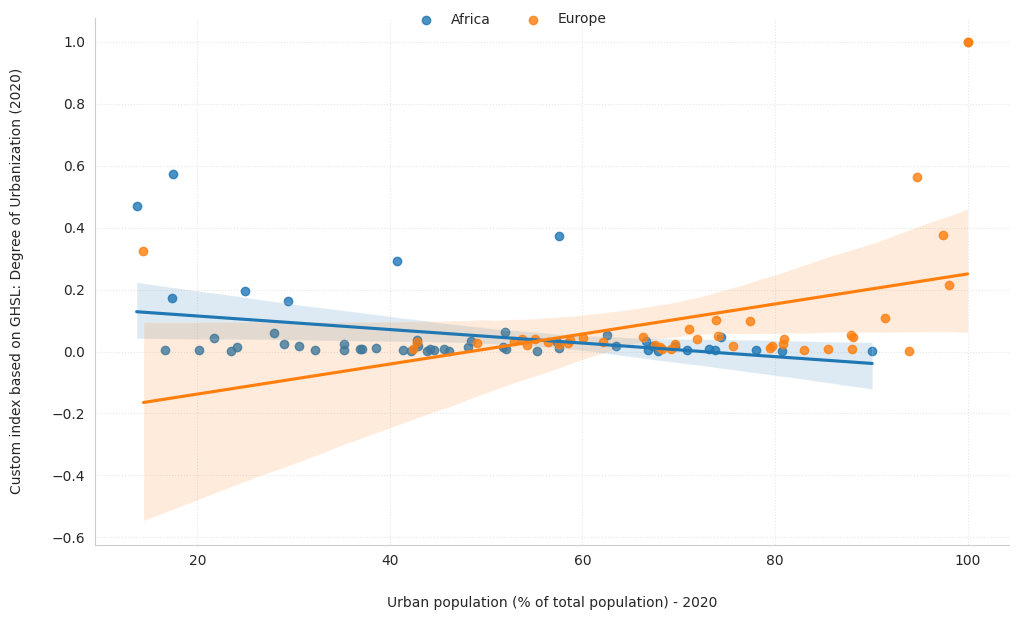

In [38]:
plot_ratio(df)

In [17]:
correlation = df['urban_population'].corr(df['custom_ratio'])
print(f"The correlation between urban_population and custom_ratio is: {correlation:.4f}")

The correlation between urban_population and custom_ratio is: -0.1555


### Medium

In [39]:
df = df_base.copy()
df["is_rural"] = df.smod_code < 13

df = df.drop(
    columns=[
        "lat",
        "lon",
        "ghsl_population",
        "ghsl_surface",
        "black_marble_radiance_monthly",
        "smod_code",
        "admin_1_code",
        "smod_class"
    ]
)

In [40]:
groupby_cols = ["continent", "country_code", "country_name", "urban_population"]
df = df.groupby(groupby_cols, observed=True).is_rural.agg(
    rural=("sum"), urban=lambda x: x.count() - x.sum()
).reset_index()

In [41]:
df["custom_ratio"] = df.urban / (df.rural + df.urban)

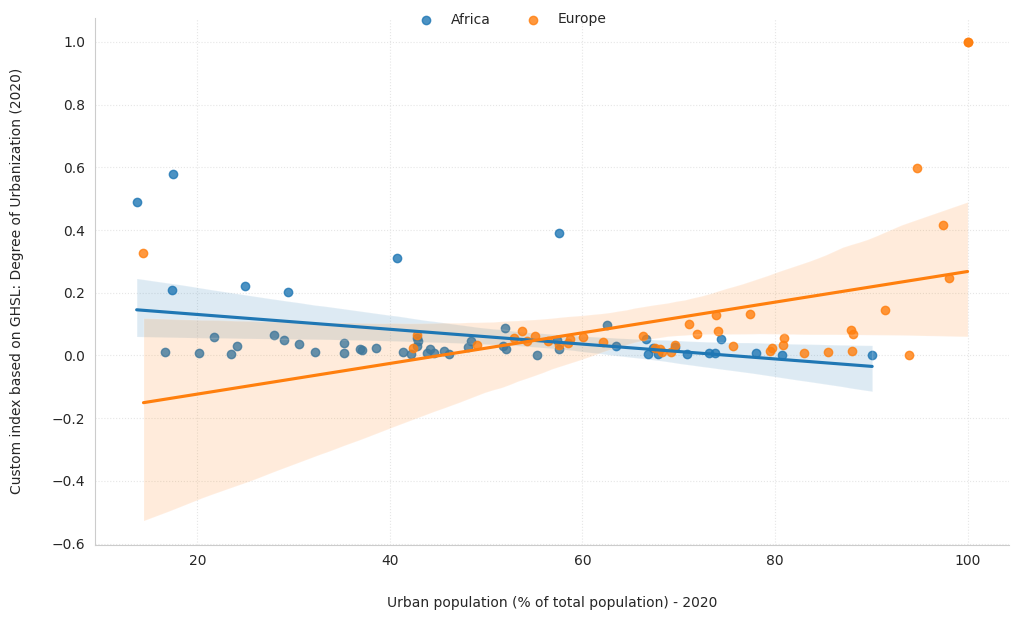

In [42]:
plot_ratio(df)

In [43]:
correlation = df['urban_population'].corr(df['custom_ratio'])
print(f"The correlation between urban_population and custom_ratio is: {correlation:.4f}")

The correlation between urban_population and custom_ratio is: 0.1542


### Hard

In [44]:
df = df_base.copy()
df["is_rural"] = df.smod_code < 12

df = df.drop(
    columns=[
        "lat",
        "lon",
        "ghsl_population",
        "ghsl_surface",
        "black_marble_radiance_monthly",
        "smod_code",
        "admin_1_code",
        "smod_class"
    ]
)

In [45]:
groupby_cols = ["continent", "country_code", "country_name", "urban_population"]
df = df.groupby(groupby_cols, observed=True).is_rural.agg(
    rural=("sum"), urban=lambda x: x.count() - x.sum()
).reset_index()

In [46]:
df["custom_ratio"] = df.urban / (df.rural + df.urban)

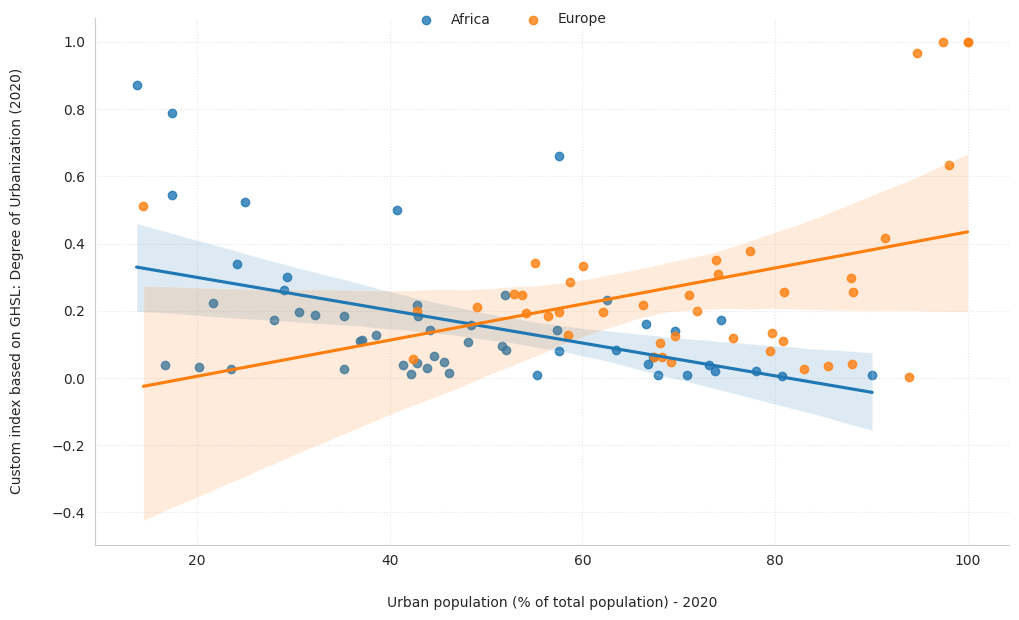

In [47]:
plot_ratio(df)

In [48]:
correlation = df['urban_population'].corr(df['custom_ratio'])
print(f"The correlation between urban_population and custom_ratio is: {correlation:.4f}")

The correlation between urban_population and custom_ratio is: 0.0953


## Radiance Values of Iceland

In [49]:
df = pd.read_parquet(
    "results/urbanization",
    filters=[("country_code", "==", "ISL")],
)
df = df[(~df.smod_code.isin([-200, 10])) & (df.black_marble_radiance_monthly >= 0)]
df["smod_class"] = df["smod_code"].map(SMOD_CODE_MAPPING)
df["smod_class"] = pd.Categorical(
    df["smod_class"],
    categories=SMOD_CLASS_ORDER,
    ordered=True
)

In [50]:
df = df[["black_marble_radiance_monthly", "smod_class"]]

In [51]:
df.groupby(by=["smod_class"], observed=False).agg(
    mean_radiance=('black_marble_radiance_monthly', 'mean'),
    count=('smod_class', 'count')
).reset_index()

,smod_class,mean_radiance,count
0,Very low density rural,0.156267,54505
1,Low density rural,27.180628,51
2,Rural cluster,22.854332,4
3,Suburban or peri-urban,31.863749,15
4,Semi-dense urban cluster,20.868088,4
5,Dense urban cluster,87.238647,1
6,Urban centre,86.383972,23


In [53]:
df[df.smod_class == "Urban centre"].describe()

,black_marble_radiance_monthly
count,23.000000
mean,86.383972
std,19.406866
min,42.996368
25%,75.660049
50%,86.368629
75%,97.722961
max,119.173576


## Japan

In [81]:
df = pd.read_parquet(
    "results/urbanization",
    filters=[("country_code", "in", ["JPN", "KOR"])],
)
df = df[(~df.smod_code.isin([-200, 10])) & (df.black_marble_radiance_monthly >= 0)]
df["smod_class"] = df["smod_code"].map(SMOD_CODE_MAPPING)
df["smod_class"] = pd.Categorical(
    df["smod_class"],
    categories=SMOD_CLASS_ORDER,
    ordered=True
)
df["bm_binary"] = df.black_marble_radiance_monthly > 1

df.continent = df.continent.cat.remove_unused_categories()
df.country_code = df.country_code.cat.remove_unused_categories()

In [82]:
df_grouped = df.groupby(by=["smod_class", "country_code"], observed=False).agg(
    mean_radiance=('black_marble_radiance_monthly', 'mean'),
    count=('smod_class', 'count')
).reset_index()

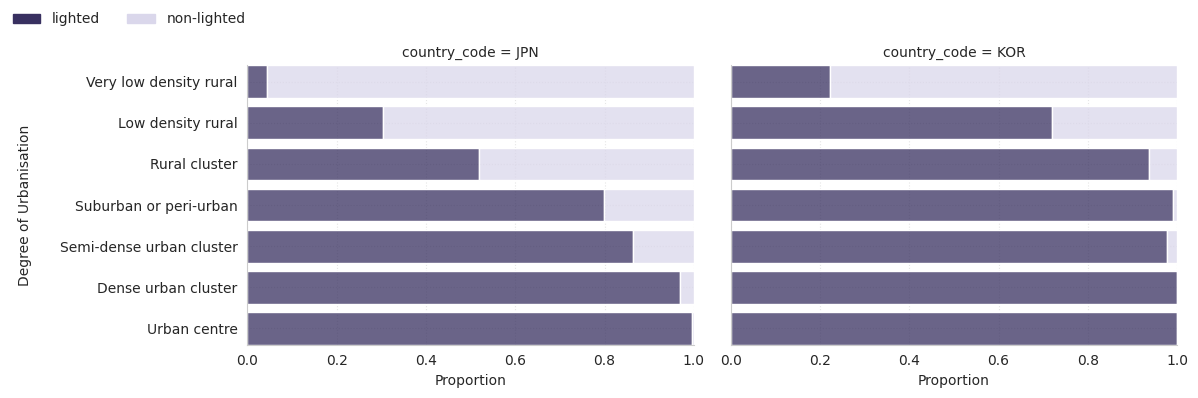

In [83]:
from conflict_monitoring_ntl.viz import plot_lighted_proportion_comparison_by_urbanisation


plot_lighted_proportion_comparison_by_urbanisation(df, col="country_code")

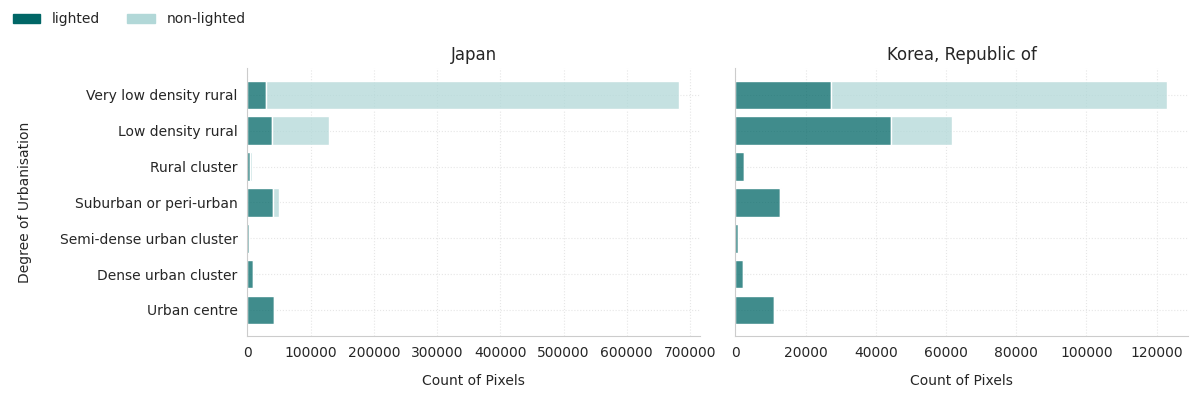

In [84]:
from conflict_monitoring_ntl.viz import plot_lighted_country_comparison_by_urbanisation


plot_lighted_country_comparison_by_urbanisation(df)